# Time to slice and dice

Most of the time, the data you work with won’t be perfectly prepared for training models. In this section we’ll explore the various features that 🤗 Datasets provides to clean up your datasets.

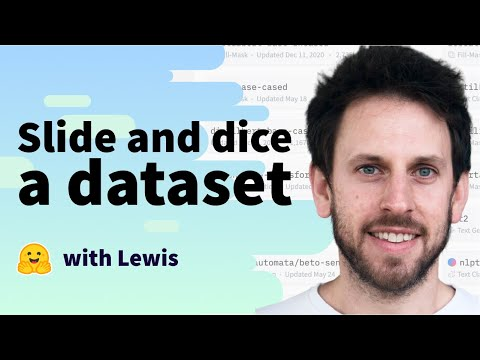

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("tqfSFcPMgOI", width=800, height=450)

## Slicing and dicing our data

Similar to Pandas, 🤗 Datasets provides several functions to manipulate the contents of `Dataset` and `DatasetDict` objects. We already encountered the `Dataset.map()` method in [Chapter 3](https://huggingface.co/course/chapter3), and in this section we’ll explore some of the other functions at our disposal.

For this example we’ll use the [Drug Review Dataset](https://archive.ics.uci.edu/ml/datasets/Drug+Review+Dataset+%28Drugs.com%29) that’s hosted on the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php), which contains patient reviews on various drugs, along with the condition being treated and a 10-star rating of the patient’s satisfaction.

First we need to download and extract the data, which can be done with the `wget` and `unzip` commands:

In [2]:
!rm -rf ./drugsCom*
!wget -qq "https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip" --show-progress
!unzip drugsCom_raw.zip

drugsCom_raw.zip        [                <=> ]  41.00M  4.12MB/s    in 29s     
Archive:  drugsCom_raw.zip
  inflating: drugsComTest_raw.tsv    
  inflating: drugsComTrain_raw.tsv   


---

Since TSV is just a variant of CSV that uses tabs instead of commas as the separator, we can load these files by using the `csv` loading script and specifying the `delimiter` argument in the `load_dataset()` function as follows:

In [3]:
from datasets import load_dataset

data_files = {
    "train": "drugsComTrain_raw.tsv", 
    "test": "drugsComTest_raw.tsv"
}

drug_dataset = load_dataset("csv", data_files=data_files, delimiter="\t")

---

A good practice when doing any sort of data analysis is to grab a small random sample to get a quick feel for the type of data you’re working with. In 🤗 Datasets, we can create a random sample by chaining the `Dataset.shuffle()` and `Dataset.select()` functions together:

In [4]:
drug_sample = drug_dataset["train"].shuffle(seed=42).select(range(1000))

for k, varr in drug_sample[0:3].items():
    print(f"`{k}`:")
    for v in varr:
        print(f" - {v}")
    print()

`Unnamed: 0`:
 - 87571
 - 178045
 - 80482

`drugName`:
 - Naproxen
 - Duloxetine
 - Mobic

`condition`:
 - Gout, Acute
 - ibromyalgia
 - Inflammatory Conditions

`review`:
 - "like the previous person mention, I&#039;m a strong believer of aleve, it works faster for my gout than the prescription meds I take. No more going to the doctor for refills.....Aleve works!"
 - "I have taken Cymbalta for about a year and a half for fibromyalgia pain. It is great
as a pain reducer and an anti-depressant, however, the side effects outweighed 
any benefit I got from it. I had trouble with restlessness, being tired constantly,
dizziness, dry mouth, numbness and tingling in my feet, and horrible sweating. I am
being weaned off of it now. Went from 60 mg to 30mg and now to 15 mg. I will be
off completely in about a week. The fibro pain is coming back, but I would rather deal with it than the side effects."
 - "I have been taking Mobic for over a year with no side effects other than an elevated blood p

---

Note that we’ve fixed the seed in `Dataset.shuffle()` for reproducibility purposes. `Dataset.select()` expects an iterable of indices, so we’ve passed `range(1000)` to grab the first 1,000 examples from the shuffled dataset. From this sample we can already see a few quirks in our dataset:

- The `Unnamed: 0` column looks suspiciously like an anonymized ID for each patient.
- The `condition` column includes a mix of uppercase and lowercase labels.
- The reviews are of varying length and contain a mix of Python line separators ("`\r\n`") as well as HTML character codes like "`&\#039;`".

Let’s see how we can use 🤗 Datasets to deal with each of these issues. To test the patient ID hypothesis for the Unnamed: 0 column, we can use the Dataset.unique() function to verify that the number of IDs matches the number of rows in each split:

In [5]:
for split in drug_dataset.keys():
    assert len(drug_dataset[split]) == len(drug_dataset[split].unique("Unnamed: 0"))

---

This seems to confirm our hypothesis, so let’s clean up the dataset a bit by renaming the Unnamed: 0 column to something a bit more interpretable. We can use the DatasetDict.rename_column() function to rename the column across both splits in one go:

In [6]:
drug_dataset = drug_dataset.rename_column(
    original_column_name="Unnamed: 0", 
    new_column_name="patient_id"
)

drug_dataset

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 161297
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 53766
    })
})

> ✏️ Try it out! Use the `Dataset.unique()` function to find the number of unique drugs and conditions in the training and test sets.

In [7]:
ud = len(drug_dataset['train'].unique("drugName"))
uc = len(drug_dataset['train'].unique("condition"))

ud, uc

(3436, 885)

Next, let’s normalize all the `condition` labels using `Dataset.map()`. As we did with tokenization in [Chapter 3](https://huggingface.co/course/chapter3), we can define a simple function that can be applied across all the rows of each split in drug_dataset:

In [8]:
drug_dataset = drug_dataset.filter(lambda x: x['condition'])

> NOTE: note that the returned dictionary only contains single key which needs to be modified.

In [9]:
drug_dataset = drug_dataset.map(lambda x: {"condition": x["condition"].lower()})

In [10]:
drug_dataset["train"]["condition"][:3]

['left ventricular dysfunction', 'adhd', 'birth control']

It works! Now that we’ve cleaned up the labels, let’s take a look at cleaning up the reviews themselves.

## Creating new columns

Whenever you’re dealing with customer reviews, a good practice is to check the number of words in each review. A review might be just a single word like “Great!” or a full-blown essay with thousands of words, and depending on the use case you’ll need to handle these extremes differently. To compute the number of words in each review, we’ll use a rough heuristic based on splitting each text by whitespace.

Let’s define a simple function that counts the number of words in each review:

> Similar to lower case map function like above, new column which needs to be created can also be returned. It will not affect the other keys.

In [11]:
drug_dataset = drug_dataset.map(lambda x: {'review_length': len(x['review'].split())})
drug_dataset["train"][0]

{'patient_id': 206461,
 'drugName': 'Valsartan',
 'condition': 'left ventricular dysfunction',
 'review': '"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"',
 'rating': 9.0,
 'date': 'May 20, 2012',
 'usefulCount': 27,
 'review_length': 17}

As expected, we can see a `review_length` column has been added to our training set. We can sort this new column with `Dataset.sort()` to see what the extreme values look like:

In [12]:
drug_dataset["train"].sort(column_names="review_length")[:3]

{'patient_id': [111469, 13653, 53602],
 'drugName': ['Ledipasvir / sofosbuvir',
  'Amphetamine / dextroamphetamine',
  'Alesse'],
 'condition': ['hepatitis c', 'adhd', 'birth control'],
 'review': ['"Headache"', '"Great"', '"Awesome"'],
 'rating': [10.0, 10.0, 10.0],
 'date': ['February 3, 2015', 'October 20, 2009', 'November 23, 2015'],
 'usefulCount': [41, 3, 0],
 'review_length': [1, 1, 1]}

---

As we suspected, some reviews contain just a single word, which, although it may be okay for sentiment analysis, would not be informative if we want to predict the condition.

> 🙋 An alternative way to add new columns to a dataset is with the `Dataset.add_column()` function. This allows you to provide the column as a Python list or NumPy array and can be handy in situations where `Dataset.map()` is not well suited for your analysis.

Let’s use the `Dataset.filter()` function to remove reviews that contain fewer than 30 words. Similarly to what we did with the condition column, we can filter out the very short reviews by requiring that the reviews have a length above this threshold:

In [13]:
drug_dataset = drug_dataset.filter(lambda x: x["review_length"] > 30)
drug_dataset.num_rows

{'train': 138514, 'test': 46108}

As you can see, this has removed around 15% of the reviews from our original training and test sets.

> ✏️ Try it out! Use the `Dataset.sort()` function to inspect the reviews with the largest numbers of words. See the [documentation](https://huggingface.co/docs/datasets/package_reference/main_classes#datasets.Dataset.sort) to see which argument you need to use sort the reviews by length in descending order.

---

The last thing we need to deal with is the presence of HTML character codes in our reviews. We can use Python’s html module to unescape these characters, like so:

In [14]:
import html

text = "I&#039;m a transformer called BERT"
html.unescape(text)

"I'm a transformer called BERT"

We’ll use `Dataset.map()` to unescape all the HTML characters in our corpus:

In [15]:
drug_dataset_unescaped = drug_dataset.map(
    function=lambda x: {"review": str(html.unescape(x["review"]))},
    load_from_cache_file=False
)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

---

As you can see, the `Dataset.map()` method is quite useful for processing data — and we haven’t even scratched the surface of everything it can do!

## The map() method’s superpowers

The `Dataset.map()` method takes a batched argument that, if set to `True`, causes it to send a batch of examples to the map function at once (the batch size is configurable but defaults to 1,000). For instance, the previous map function that unescaped all the HTML took a bit of time to run (you can read the time taken from the progress bars). We can speed this up by processing several elements at the same time using a list comprehension.

When you specify `batched=True` the function receives a dictionary with the fields of the dataset, but each value is now a list of values, and not just a single value. The return value of `Dataset.map()` should be the same: a dictionary with the fields we want to update or add to our dataset, and a list of values. For example, here is another way to unescape all HTML characters, but using `batched=True`:

> NOTE ⚠️: When `batched=True` is set, the corresponding lambda function receives lists instead of elements.
>
> Since `html.unescape` supports the processing of `list[str]` type, I am converting each element to string to verify the claim.

In [16]:
try:
    new_drug_dataset_unescaped = drug_dataset.map(
        function=lambda x: {"review": str(html.unescape(x["review"]))},
        load_from_cache_file=False,
        batched=True,
        batch_size=64
    )
except:
    print('PROCESSING FAILED!')

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

PROCESSING FAILED!


In [17]:
drug_dataset = drug_dataset.map(
    function=lambda x: {"review": [str(html.unescape(o)) for o in x["review"]]},
    load_from_cache_file=False,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

---

If you’re running this code in a notebook, you’ll see that this command executes way faster than the previous one. And it’s not because our reviews have already been HTML-unescaped — if you re-execute the instruction from the previous section (without `batched=True`), it will take the same amount of time as before. This is because list comprehensions are usually faster than executing the same code in a `for` loop, and we also gain some performance by accessing lots of elements at the same time instead of one by one.

Using `Dataset.map()` with `batched=True` will be essential to unlock the speed of the “fast” tokenizers that we’ll encounter in [Chapter 6](https://huggingface.co/course/chapter6), which can quickly tokenize big lists of texts. For instance, to tokenize all the drug reviews with a fast tokenizer, we could use a function like this:

### Tokenizers.map() Superpowers:

In [18]:
from transformers import AutoTokenizer

slow_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", use_fast=False)
fast_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", use_fast=True)

#### Speed Comparisions:

##### A. No Batched

---

A1. `slow_tokenizer`, `without num_proc=4`

In [19]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: slow_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False
)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 36 s, sys: 405 ms, total: 36.4 s
Wall time: 36.7 s


---

A2. `fast_tokenizer`, `without num_proc=4`

In [20]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: fast_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False
)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 35.2 s, sys: 291 ms, total: 35.5 s
Wall time: 35.7 s


---

A3. `slow_tokenizer`, `with num_proc=4`

In [21]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: slow_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False,
    num_proc=4
)

Map (num_proc=4):   0%|          | 0/138514 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 362 ms, sys: 130 ms, total: 492 ms
Wall time: 35.8 s


---

A4. `fast_tokenizer`, `with num_proc=4`

In [22]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: fast_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False,
    num_proc=4
)

Map (num_proc=4):   0%|          | 0/138514 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 345 ms, sys: 125 ms, total: 470 ms
Wall time: 35.9 s


---

#### B. Batched:

B1. `slow_tokenizer`, `without num_proc=4`

In [23]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: slow_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False,
    batched=True,
    batch_size=4096
)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 28 s, sys: 273 ms, total: 28.3 s
Wall time: 28.6 s


---

B2. `fast_tokenizer`, `without num_proc=4`

In [24]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: fast_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False,
    batched=True,
    batch_size=4096
)

Map:   0%|          | 0/138514 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 27.9 s, sys: 215 ms, total: 28.1 s
Wall time: 28.2 s


---

B3. `slow_tokenizer`, `with num_proc=4`

In [25]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: slow_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False,
    batched=True,
    batch_size=4096,
    num_proc=4
)

Map (num_proc=4):   0%|          | 0/138514 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 339 ms, sys: 96.9 ms, total: 436 ms
Wall time: 28.8 s


---

B4. `fast_tokenizer`, `with num_proc=4`

In [26]:
%%time 

tokenized_dataset = drug_dataset.map(
    lambda x: fast_tokenizer(x['review'], truncation=True), 
    load_from_cache_file=False,
    batched=True,
    batch_size=4096,
    num_proc=4
)

Map (num_proc=4):   0%|          | 0/138514 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/46108 [00:00<?, ? examples/s]

CPU times: user 233 ms, sys: 115 ms, total: 348 ms
Wall time: 8.91 s


Those are much more reasonable results for the slow tokenizer, but the performance of the fast tokenizer was also substantially improved. Note, however, that won’t always be the case — for values of `num_proc` other than 8, our tests showed that it was faster to use `batched=True` without that option. In general, we don’t recommend using Python multiprocessing for fast tokenizers with `batched=True`.

> Using `num_proc` to speed up your processing is usually a great idea, as long as the function you are using is not already doing some kind of multiprocessing of its own.

All of this functionality condensed into a single method is already pretty amazing, but there’s more! With `Dataset.map()` and `batched=True` you can change the number of elements in your dataset. This is super useful in many situations where you want to create several training features from one example, and we will need to do this as part of the preprocessing for several of the NLP tasks we’ll undertake in [Chapter 7](https://huggingface.co/course/chapter7).

> 💡 In machine learning, an example is usually defined as the set of features that we feed to the model. In some contexts, these features will be the set of columns in a `Dataset`, but in others (like here and for question answering), multiple features can be extracted from a single example and belong to a single column.

---

Let’s have a look at how it works! Here we will tokenize our examples and truncate them to a maximum length of 128, but we will ask the tokenizer to return all the chunks of the texts instead of just the first one. This can be done with `return_overflowing_tokens=True`:

In [27]:
output = fast_tokenizer(
    list(drug_dataset['train'].take(1)['review']),
    truncation=True,
    max_length=128,
    return_overflowing_tokens=True,
)

In [28]:
for k, varr in output.items():
    print(f"`{k}`")
    for v in varr:
        print(f"- {v}")
    print()

`input_ids`
- [101, 107, 1422, 1488, 1110, 9079, 1194, 1117, 2223, 1989, 1104, 1130, 19972, 11083, 119, 1284, 1245, 4264, 1165, 1119, 1310, 1142, 1314, 1989, 117, 1165, 1119, 1408, 1781, 1103, 2439, 13753, 1119, 1209, 1129, 1113, 119, 1370, 1160, 1552, 117, 1119, 1180, 6374, 1243, 1149, 1104, 1908, 117, 1108, 1304, 172, 14687, 1183, 117, 1105, 7362, 1111, 2212, 129, 2005, 1113, 170, 2797, 1313, 1121, 1278, 12020, 113, 1304, 5283, 1111, 1140, 119, 114, 146, 1270, 1117, 3995, 1113, 6356, 2106, 1105, 1131, 1163, 1106, 6166, 1122, 1149, 170, 1374, 1552, 119, 3969, 1293, 1119, 1225, 1120, 1278, 117, 1105, 1114, 2033, 1146, 1107, 1103, 2106, 119, 1109, 1314, 1160, 1552, 1138, 1151, 2463, 1714, 119, 1124, 1110, 150, 21986, 3048, 1167, 5340, 1895, 1190, 1518, 102]
- [101, 119, 1124, 1110, 1750, 6438, 113, 170, 1363, 1645, 114, 117, 1750, 172, 14687, 1183, 119, 1124, 1110, 11566, 1155, 1103, 1614, 1119, 1431, 119, 8007, 1117, 4658, 1110, 1618, 119, 1284, 1138, 1793, 1242, 1472, 23897, 1105, 117

In [29]:
sample_map = output.pop('overflow_to_sample_mapping')
sample_map

[0, 0]

In [30]:
examples = drug_dataset['train'].take(1)[:]
examples

{'patient_id': [95260],
 'drugName': ['Guanfacine'],
 'condition': ['adhd'],
 'review': ['"My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.) I called his doctor on Monday morning and she said to stick it out a few days. See how he did at school, and with getting up in the morning. The last two days have been problem free. He is MUCH more agreeable than ever. He is less emotional (a good thing), less cranky. He is remembering all the things he should. Overall his behavior is better. \r\nWe have tried many different medications and so far this is the most effective."'],
 'rating': [8.0],
 'date': ['April 27, 2010'],
 'usefulCount': [192],
 'review_length': [141]}

In [31]:
for key, values in examples.items():
    output[key] = [values[i] for i in sample_map]

In [32]:
for k, varr in output.items():
    print(f"`{k}`")
    for v in varr:
        print(f"- {v}")
    print()

`input_ids`
- [101, 107, 1422, 1488, 1110, 9079, 1194, 1117, 2223, 1989, 1104, 1130, 19972, 11083, 119, 1284, 1245, 4264, 1165, 1119, 1310, 1142, 1314, 1989, 117, 1165, 1119, 1408, 1781, 1103, 2439, 13753, 1119, 1209, 1129, 1113, 119, 1370, 1160, 1552, 117, 1119, 1180, 6374, 1243, 1149, 1104, 1908, 117, 1108, 1304, 172, 14687, 1183, 117, 1105, 7362, 1111, 2212, 129, 2005, 1113, 170, 2797, 1313, 1121, 1278, 12020, 113, 1304, 5283, 1111, 1140, 119, 114, 146, 1270, 1117, 3995, 1113, 6356, 2106, 1105, 1131, 1163, 1106, 6166, 1122, 1149, 170, 1374, 1552, 119, 3969, 1293, 1119, 1225, 1120, 1278, 117, 1105, 1114, 2033, 1146, 1107, 1103, 2106, 119, 1109, 1314, 1160, 1552, 1138, 1151, 2463, 1714, 119, 1124, 1110, 150, 21986, 3048, 1167, 5340, 1895, 1190, 1518, 102]
- [101, 119, 1124, 1110, 1750, 6438, 113, 170, 1363, 1645, 114, 117, 1750, 172, 14687, 1183, 119, 1124, 1110, 11566, 1155, 1103, 1614, 1119, 1431, 119, 8007, 1117, 4658, 1110, 1618, 119, 1284, 1138, 1793, 1242, 1472, 23897, 1105, 117

> So, this will simply replicate the columns corresponding to all the splitted segments.
> 
> If we want, we can keep the splitted segments by dropping other columns from the dataset. See below example for the same.

In [33]:
tokenized_dataset = drug_dataset.map(
    function=lambda x: fast_tokenizer(
        text=x['review'], 
        max_length=128, 
        truncation=True, 
        return_overflowing_tokens=True
    ),
    batched=True,
    remove_columns=drug_dataset["train"].column_names
)

In [34]:
drug_dataset.num_rows

{'train': 138514, 'test': 46108}

In [35]:
tokenized_dataset.num_rows

{'train': 206772, 'test': 68876}

## From Datasets to DataFrames and back

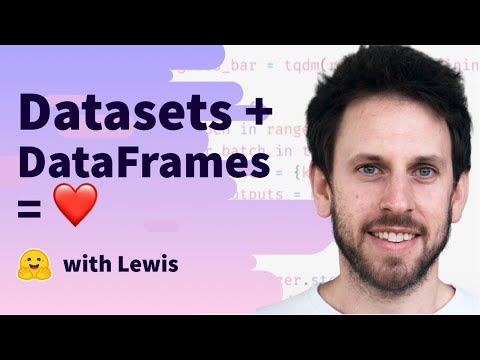

In [36]:
from IPython.display import YouTubeVideo

YouTubeVideo("tfcY1067A5Q", width=800, height=450)

To enable the conversion between various third-party libraries, 🤗 Datasets provides a `Dataset.set_format()` function. This function only changes the *output format* of the dataset, so you can easily switch to another format without affecting the underlying *data format*, which is Apache Arrow. The formatting is done in place. To demonstrate, let’s convert our dataset to Pandas:

In [37]:
drug_dataset.set_format("pandas")

> Now when we access elements of the dataset we get a `pandas.DataFrame` instead of a dictionary:

In [38]:
drug_dataset["train"][:3]

,patient_id,drugName,condition,review,rating,date,usefulCount,review_length
0,95260,Guanfacine,adhd,"""My son is halfway through his fourth week of ...",8.0,"April 27, 2010",192,141
1,92703,Lybrel,birth control,"""I used to take another oral contraceptive, wh...",5.0,"December 14, 2009",17,134
2,138000,Ortho Evra,birth control,"""This is my first time using any form of birth...",8.0,"November 3, 2015",10,89


---

Let’s create a `pandas.DataFrame` for the whole training set by selecting all the elements of `drug_dataset["train"]`:

In [39]:
train_df = drug_dataset["train"][:]

> 🚨 Under the hood, `Dataset.set_format()` changes the return format for the dataset’s `__getitem__()` dunder method. This means that when we want to create a new object like `train_df` from a Dataset in the "pandas" format, we need to slice the whole dataset to obtain a `pandas.DataFrame`. You can verify for yourself that the type of `drug_dataset["train"]` is `Dataset`, irrespective of the output format.

---

From here we can use all the Pandas functionality that we want. For example, we can do fancy chaining to compute the class distribution among the condition entries:

In [40]:
train_df["condition"]

0                                 adhd
1                        birth control
2                        birth control
3                    opiate dependence
4         benign prostatic hyperplasia
                      ...             
138509                   birth control
138510              alcohol dependence
138511                 nausea/vomiting
138512             underactive thyroid
138513           constipation, chronic
Name: condition, Length: 138514, dtype: str

In [41]:
train_df["condition"].value_counts()

condition
birth control                                  27655
depression                                      8023
acne                                            5209
anxiety                                         4991
pain                                            4744
                                               ...  
tinea barbae                                       1
acute nonlymphocytic leukemia                      1
intermittent explosive disorde                     1
62</span> users found this comment helpful.        1
neutropenia                                        1
Name: count, Length: 819, dtype: int64

In [42]:
train_df["condition"].value_counts().to_frame()

,count
condition,
birth control,27655
depression,8023
acne,5209
anxiety,4991
pain,4744
...,...
tinea barbae,1
acute nonlymphocytic leukemia,1
intermittent explosive disorde,1


In [43]:
train_df["condition"].value_counts().to_frame().reset_index()

,condition,count
0,birth control,27655
1,depression,8023
2,acne,5209
3,anxiety,4991
4,pain,4744
...,...,...
814,tinea barbae,1
815,acute nonlymphocytic leukemia,1
816,intermittent explosive disorde,1
817,62</span> users found this comment helpful.,1


In [44]:
output = train_df["condition"].value_counts().to_frame().reset_index().rename(columns={"index": "condition", "count": "frequency"})
output

,condition,frequency
0,birth control,27655
1,depression,8023
2,acne,5209
3,anxiety,4991
4,pain,4744
...,...,...
814,tinea barbae,1
815,acute nonlymphocytic leukemia,1
816,intermittent explosive disorde,1
817,62</span> users found this comment helpful.,1


In [45]:
frequencies = (output)
frequencies

,condition,frequency
0,birth control,27655
1,depression,8023
2,acne,5209
3,anxiety,4991
4,pain,4744
...,...,...
814,tinea barbae,1
815,acute nonlymphocytic leukemia,1
816,intermittent explosive disorde,1
817,62</span> users found this comment helpful.,1


In [46]:
frequencies.head()

,condition,frequency
0,birth control,27655
1,depression,8023
2,acne,5209
3,anxiety,4991
4,pain,4744


And once we’re done with our `Pandas` analysis, we can always create a new `Dataset` object by using the `Dataset.from_pandas()` function as follows:

In [47]:
from datasets import Dataset

freq_dataset = Dataset.from_pandas(frequencies)
freq_dataset

Dataset({
    features: ['condition', 'frequency'],
    num_rows: 819
})

> ✏️ Try it out! Compute the average rating per drug and store the result in a new `Dataset`.

This wraps up our tour of the various preprocessing techniques available in 🤗 Datasets. To round out the section, let’s create a validation set to prepare the dataset for training a classifier on. Before doing so, we’ll reset the output format of `drug_dataset` from `"pandas"` to `"arrow"`:

In [48]:
drug_dataset.reset_format()

## Creating a validation set

Although we have a test set we could use for evaluation, it’s a good practice to leave the test set untouched and create a separate validation set during development. Once you are happy with the performance of your models on the validation set, you can do a final sanity check on the test set. This process helps mitigate the risk that you’ll overfit to the test set and deploy a model that fails on real-world data.

---

🤗 Datasets provides a `Dataset.train_test_split()` function that is based on the famous functionality from `scikit-learn`. Let’s use it to split our training set into `train` and `validation` splits (we set the `seed` argument for reproducibility):

In [49]:
drug_dataset_clean = drug_dataset["train"].train_test_split(train_size=0.8, seed=42)

# Rename the default "test" split to "validation"
drug_dataset_clean["validation"] = drug_dataset_clean.pop("test")

# Add the "test" set to our `DatasetDict`
drug_dataset_clean["test"] = drug_dataset["test"]

drug_dataset_clean

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 110811
    })
    validation: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 27703
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 46108
    })
})

---

Great, we’ve now prepared a dataset that’s ready for training some models on! In [section 5](https://huggingface.co/course/chapter5/5) we’ll show you how to upload datasets to the Hugging Face Hub, but for now let’s cap off our analysis by looking at a few ways you can save datasets on your local machine.

## Saving a dataset

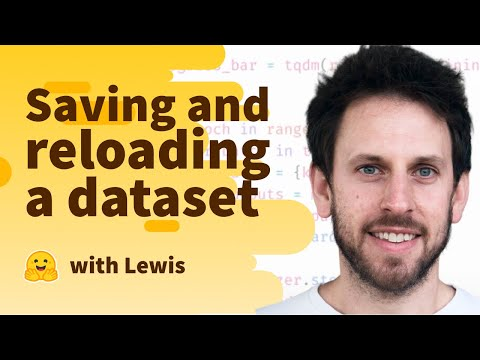

In [50]:
from IPython.display import YouTubeVideo

YouTubeVideo("blF9uxYcKHo", width=800, height=450)

Although 🤗 Datasets will cache every downloaded dataset and the operations performed on it, there are times when you’ll want to save a dataset to disk (e.g., in case the cache gets deleted). As shown in the table below, 🤗 Datasets provides three main functions to save your dataset in different formats:

|Data format|Function|
|---|---|
|Arrow|`Dataset.save_to_disk()`|
|CSV|`Dataset.to_csv()`|
|JSON|`Dataset.to_json()`|

For example, let’s save our cleaned dataset in the Arrow format:

In [51]:
drug_dataset_clean.save_to_disk("hf_cache/drug-reviews")

Saving the dataset (0/1 shards):   0%|          | 0/110811 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/27703 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/46108 [00:00<?, ? examples/s]

This will create a directory with the following structure:

```
hf_cache/drug-reviews/
├── dataset_dict.json
├── test
│   ├── dataset.arrow
│   ├── dataset_info.json
│   └── state.json
├── train
│   ├── dataset.arrow
│   ├── dataset_info.json
│   ├── indices.arrow
│   └── state.json
└── validation
    ├── dataset.arrow
    ├── dataset_info.json
    ├── indices.arrow
    └── state.json
```

---

where we can see that each split is associated with its own `dataset.arrow` table, and some metadata in `dataset_info.json` and `state.json`. You can think of the Arrow format as a fancy table of columns and rows that is optimized for building high-performance applications that process and transport large datasets.

Once the dataset is saved, we can load it by using the `load_from_disk()` function as follows:

In [52]:
from datasets import load_from_disk

drug_dataset_reloaded = load_from_disk("hf_cache/drug-reviews")
drug_dataset_reloaded

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 110811
    })
    validation: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 27703
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_length'],
        num_rows: 46108
    })
})

---

For the CSV and JSON formats, we have to store each split as a separate file. One way to do this is by iterating over the keys and values in the `DatasetDict` object:

In [53]:
for split, dataset in drug_dataset_clean.items():
    dataset.to_json(f"hf_cache/drug-reviews-{split}.jsonl")

Creating json from Arrow format:   0%|          | 0/111 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/28 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/47 [00:00<?, ?ba/s]

---

This saves each split in [JSON Lines format](https://jsonlines.org/), where each row in the dataset is stored as a single line of JSON. Here’s what the first example looks like:

In [54]:
!head -n 1 hf_cache/drug-reviews-train.jsonl

{"patient_id":89879,"drugName":"Cyclosporine","condition":"keratoconjunctivitis sicca","review":"\"I have used Restasis for about a year now and have seen almost no progress.  For most of my life I've had red and bothersome eyes. After trying various eye drops, my doctor recommended Restasis.  He said it typically takes 3 to 6 months for it to really kick in but it never did kick in.  When I put the drops in it burns my eyes for the first 30 - 40 minutes.  I've talked with my doctor about this and he said it is normal but should go away after some time, but it hasn't. Every year around spring time my eyes get terrible irritated  and this year has been the same (maybe even worse than other years) even though I've been using Restasis for a year now. The only difference I notice was for the first couple weeks, but now I'm ready to move on.\"","rating":2.0,"date":"April 20, 2013","usefulCount":69,"review_length":147}


---

We can then use the techniques from [section 2](https://huggingface.co/course/chapter5/2) to load the JSON files as follows:

In [55]:
data_files = {
    "train": "hf_cache/drug-reviews-train.jsonl",
    "validation": "hf_cache/drug-reviews-validation.jsonl",
    "test": "hf_cache/drug-reviews-test.jsonl",
}

drug_dataset_reloaded = load_dataset("json", data_files=data_files)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

---

And that’s it for our excursion into data wrangling with 🤗 Datasets! Now that we have a cleaned dataset for training a model on, here are a few ideas that you could try out:

1. Use the techniques from [Chapter 3](https://huggingface.co/course/chapter3) to train a classifier that can predict the patient condition based on the drug review.
2. Use the `summarization` pipeline from [Chapter 1](https://huggingface.co/course/chapter1) to generate summaries of the reviews.

Next, we’ll take a look at how 🤗 Datasets can enable you to work with huge datasets without blowing up your laptop!